### Business Objective

A company that buys and sells used cars wants to estimate the selling price of vehicles automatically.

Currently:

Pricing is done manually.
Human estimates are inconsistent.
Incorrect pricing causes losses.

The objective is:

Predict the resale value of a used car using historical vehicle information.

In [104]:
import mlflow
from mlflow.models import infer_signature

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [105]:
import os
print(os.getcwd())

e:\vs_project\Used_Car_Prediction\notebooks


In [106]:
df_raw=pd.read_csv(r"E:\vs_project\Used_Car_Prediction\data\raw\used_car.csv")

In [107]:
df_raw.head()

,Location,Fuel_Type,Transmission,Owner_Type,Seats,Price,mileage_new,engine_new,power_new,age,make,model,KM_Driven
0,Chennai,Petrol,Manual,First,5.0,4.50,18.20,1199,88.70,9,honda,jazz,46
1,Chennai,Diesel,Manual,First,7.0,6.00,20.77,1248,88.76,8,maruti,ertiga,87
2,Jaipur,Diesel,Manual,First,5.0,3.50,23.08,1461,63.10,7,nissan,micra,86
3,Chennai,Diesel,Manual,Second,5.0,1.95,22.30,1248,74.00,8,tata,indica,65
4,Jaipur,Diesel,Manual,First,5.0,5.60,25.20,1248,74.00,5,maruti,swift,64


In [108]:
df_raw.shape

(3092, 13)

In [109]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3092 entries, 0 to 3091
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Location      3092 non-null   object 
 1   Fuel_Type     3092 non-null   object 
 2   Transmission  3092 non-null   object 
 3   Owner_Type    3092 non-null   object 
 4   Seats         3091 non-null   float64
 5   Price         3092 non-null   float64
 6   mileage_new   3092 non-null   float64
 7   engine_new    3092 non-null   int64  
 8   power_new     3092 non-null   float64
 9   age           3092 non-null   int64  
 10  make          3092 non-null   object 
 11  model         3092 non-null   object 
 12  KM_Driven     3092 non-null   int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 314.2+ KB


In [110]:
df_raw.isnull().sum()

Location        0
Fuel_Type       0
Transmission    0
Owner_Type      0
Seats           1
Price           0
mileage_new     0
engine_new      0
power_new       0
age             0
make            0
model           0
KM_Driven       0
dtype: int64

In [111]:
df_raw.describe()

,Seats,Price,mileage_new,engine_new,power_new,age,KM_Driven
count,3091.000000,3092.000000,3092.000000,3092.000000,3092.000000,3092.000000,3092.000000
mean,5.121643,4.435783,20.558273,1234.703428,77.384719,6.434994,53.052070
std,0.557462,2.116982,3.363739,249.613330,13.336049,3.271295,30.311382
min,4.000000,0.440000,11.300000,624.000000,34.200000,1.000000,0.000000
25%,5.000000,2.850000,18.500000,1197.000000,68.050000,4.000000,31.000000
50%,5.000000,4.150000,20.360000,1198.000000,78.900000,6.000000,50.000000
75%,5.000000,5.832500,23.000000,1368.000000,88.000000,8.000000,69.000000
max,10.000000,12.900000,28.400000,2956.000000,100.000000,22.000000,180.000000


In [112]:
df_raw.duplicated().sum()

np.int64(11)

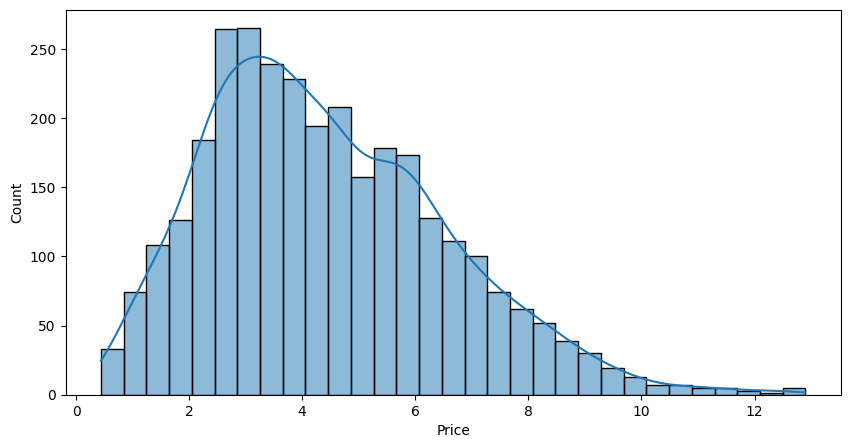

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    df_raw["Price"],
    kde=True
)

plt.show()

In [114]:
df_raw.columns

Index(['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Seats', 'Price',
       'mileage_new', 'engine_new', 'power_new', 'age', 'make', 'model',
       'KM_Driven'],
      dtype='object')

In [115]:
df_raw=df_raw.drop_duplicates()
df_raw.shape

(3081, 13)

In [116]:
x_columns = ['KM_Driven', 'Fuel_Type', 'age',
              'Transmission', 'Owner_Type', 'Seats',
              'make', 'mileage_new', 'engine_new', 'model',
              'power_new', 'Location']

In [117]:
df_raw = df_raw[x_columns + ['Price']].dropna()

In [118]:
cat_features = ['Fuel_Type',
                'Transmission', 'Owner_Type', 'model',
                'make', 'Location']

In [119]:
num_features = list(set(x_columns) - set(cat_features))

In [120]:
train, test = train_test_split(df_raw,
                               train_size = 0.8,
                               random_state = 100)

In [121]:
train.shape

(2464, 13)

In [122]:
test.shape

(616, 13)

In [123]:
train.head()

,KM_Driven,Fuel_Type,age,Transmission,Owner_Type,Seats,make,mileage_new,engine_new,model,power_new,Location,Price
2324,70,Petrol,7,Manual,Second,5.0,tata,15.40,1193,indigo,65.0,Pune,1.50
2189,56,Petrol,8,Manual,First,5.0,chevrolet,18.60,1199,beat,79.4,Delhi,2.21
2699,62,Diesel,5,Manual,First,5.0,maruti,28.40,1248,swift,74.0,Hyderabad,6.30
1207,22,Diesel,4,Manual,First,5.0,volkswagen,20.14,1498,polo,88.0,Kolkata,6.29
1532,29,Diesel,6,Manual,First,5.0,maruti,23.40,1248,swift,74.0,Bangalore,5.75


In [124]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

### Create the ML Pipeline

In [125]:
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('onehot', 
                                           OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),                  
        ('cat', categorical_transformer, cat_features),
    ])

params = { "n_estimators": 200,
           "max_depth": 4 }

xgb_regressor = GradientBoostingRegressor(**params)

reg = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', xgb_regressor)])           

reg.fit(train[x_columns], 
        train['Price'])

rmse = np.sqrt(mean_squared_error(test['Price'], 
                                  reg.predict(test[x_columns])))
r2 = r2_score(test['Price'], reg.predict(test[x_columns]))

In [126]:
print("R2 value:",r2)

R2 value: 0.9048410257891415


### Track Experiments

In [127]:
import mlflow

In [128]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:9090")

# Create a new MLflow Experiment
mlflow.set_experiment("UserCarPrice Experiment V1")

# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the loss metric
    mlflow.log_metric("rmse", rmse)
    # Log the loss metric
    mlflow.log_metric("r2", r2)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Gradient Boosting Model")

    # Infer the model signature
    signature = infer_signature(train[x_columns], 
                                reg.predict(train[x_columns]))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=reg,
        artifact_path="usedcarmodel",
        signature=signature,
        input_example=train[x_columns],
        registered_model_name="userd_car_model",
    )

e:\vs_project\Used_Car_Prediction\used_car_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/12 00:13:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 00:13:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires 

🏃 View run salty-grouse-863 at: http://127.0.0.1:9090/#/experiments/1/runs/35ae0c95626b41669157e2c6c81e3312
🧪 View experiment at: http://127.0.0.1:9090/#/experiments/1


Created version '3' of model 'userd_car_model'.
